In [13]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.linalg import expm

%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})
plt.rcParams["text.usetex"] = True

X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def commutator(a, b):
    return a @ b - b @ a


@dataclass
class SystemCache:
    n: int
    a_mat: np.ndarray
    b_mat: np.ndarray
    c1: np.ndarray
    c2: np.ndarray
    c1_l1: float
    c2_l1: float
    identity: np.ndarray
    h_total: np.ndarray


def build_periodic_ab(n: int, j: float = 1.0, h: float = 1.0):
    def xx_term(index):
        if index < n - 1:
            return j * np.kron(
                np.eye(2**index, dtype=complex),
                np.kron(np.kron(X, X), np.eye(2 ** (n - index - 2), dtype=complex)),
            )
        return j * np.kron(X, np.kron(np.eye(2 ** (n - 2), dtype=complex), X))

    def z_term(index):
        return h * np.kron(
            np.eye(2**index, dtype=complex),
            np.kron(Z, np.eye(2 ** (n - index - 1), dtype=complex)),
        )

    a_mat = np.zeros((2**n, 2**n), dtype=complex)
    b_mat = np.zeros((2**n, 2**n), dtype=complex)
    for idx in range(0, n, 2):
        a_mat += xx_term(idx) + z_term(idx)
    for idx in range(1, n, 2):
        b_mat += xx_term(idx) + z_term(idx)
    return a_mat, b_mat


def build_system_cache(n: int, j: float = 1.0, h: float = 1.0) -> SystemCache:
    a_mat, b_mat = build_periodic_ab(n, j=j, h=h)
    c1 = commutator(b_mat, a_mat)
    c2 = 1j * (2 * commutator(b_mat, commutator(a_mat, b_mat)) + commutator(a_mat, commutator(a_mat, b_mat)))
    c1_l1 = 2.0 * n * j * h
    if abs(j - h) > 1e-12:
        raise ValueError("This notebook assumes J = h.")
    c2_l1 = 24.0 * n * j * h
    dim = 2**n
    return SystemCache(
        n=n,
        a_mat=a_mat,
        b_mat=b_mat,
        c1=c1,
        c2=c2,
        c1_l1=c1_l1,
        c2_l1=c2_l1,
        identity=np.eye(dim, dtype=complex),
        h_total=a_mat + b_mat,
    )


def exact_ncc_total_error(cache: SystemCache, t_total: float, r: int) -> float:
    t = t_total / r
    eta2 = cache.c1_l1 * (t**2) / 2
    eta3 = cache.c2_l1 * (t**3) / 6
    eta_sum = eta2 + eta3
    theta = math.atan(eta_sum)

    s1 = expm(-1j * cache.b_mat * t) @ expm(-1j * cache.a_mat * t)
    v_avg = np.cos(theta) * cache.identity + (np.sin(theta) / eta_sum) * ((t**2 / 2) * cache.c1 + (t**3 / 6) * cache.c2)
    u_exact = expm(-1j * cache.h_total * t_total)
    return np.linalg.norm(np.linalg.matrix_power(v_avg @ s1, r) - u_exact, 2)


def find_min_segments(cache: SystemCache, t_total: float, epsilon: float, r_max: int = 512):
    low = 1
    high = 1
    err_high = exact_ncc_total_error(cache, t_total, high)
    while err_high > epsilon and high < r_max:
        low = high
        high *= 2
        err_high = exact_ncc_total_error(cache, t_total, high)
    if err_high > epsilon:
        raise RuntimeError(f"failed to reach epsilon={epsilon} by r={r_max}")
    while low + 1 < high:
        mid = (low + high) // 2
        err_mid = exact_ncc_total_error(cache, t_total, mid)
        if err_mid <= epsilon:
            high = mid
            err_high = err_mid
        else:
            low = mid
    return high, err_high


def fit_power_law(x, y):
    coeffs = np.polyfit(np.log(x), np.log(y), 1)
    slope = coeffs[0]
    prefactor = math.exp(coeffs[1])
    return slope, prefactor


def scaled_reference(x, y0, x0, exponent):
    return y0 * (x / x0) ** exponent


def plot_panel(ax, x, y, expected_exp, xlabel, title, invert_x=False):
    slope, prefactor = fit_power_law(np.array(x, dtype=float), np.array(y, dtype=float))
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    ref = scaled_reference(x, y[0], x[0], expected_exp)
    fit = prefactor * x**slope

    ax.loglog(x, y, "o", ms=8, color="#1f77b4", label="data")
    ax.loglog(x, ref, "--", lw=2.0, color="#d62728", label=rf"theory slope ${expected_exp:.3f}$")
    ax.loglog(x, fit, ":", lw=2.2, color="#2ca02c", label=rf"fit slope ${slope:.3f}$")
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter([f"{val:g}" for val in x]))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("min gate count")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False)
    return slope


n_values = [4, 6, 8]
t_values = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
eps_values = [2e-2, 1.5e-2, 1e-2, 7e-3, 5e-3, 3e-3]

fixed_t_for_n = 1.0
fixed_eps_for_n = 1e-2
fixed_n_for_t = 6
fixed_eps_for_t = 1e-2
fixed_n_for_eps = 6
fixed_t_for_eps = 1.0

caches = {n: build_system_cache(n) for n in sorted(set(n_values + [fixed_n_for_t, fixed_n_for_eps]))}


N sweep: N=4, r_min=12, err=8.191e-03, G=48
N sweep: N=6, r_min=15, err=8.516e-03, G=90
N sweep: N=8, r_min=17, err=9.884e-03, G=136
fitted slope (N): 1.506


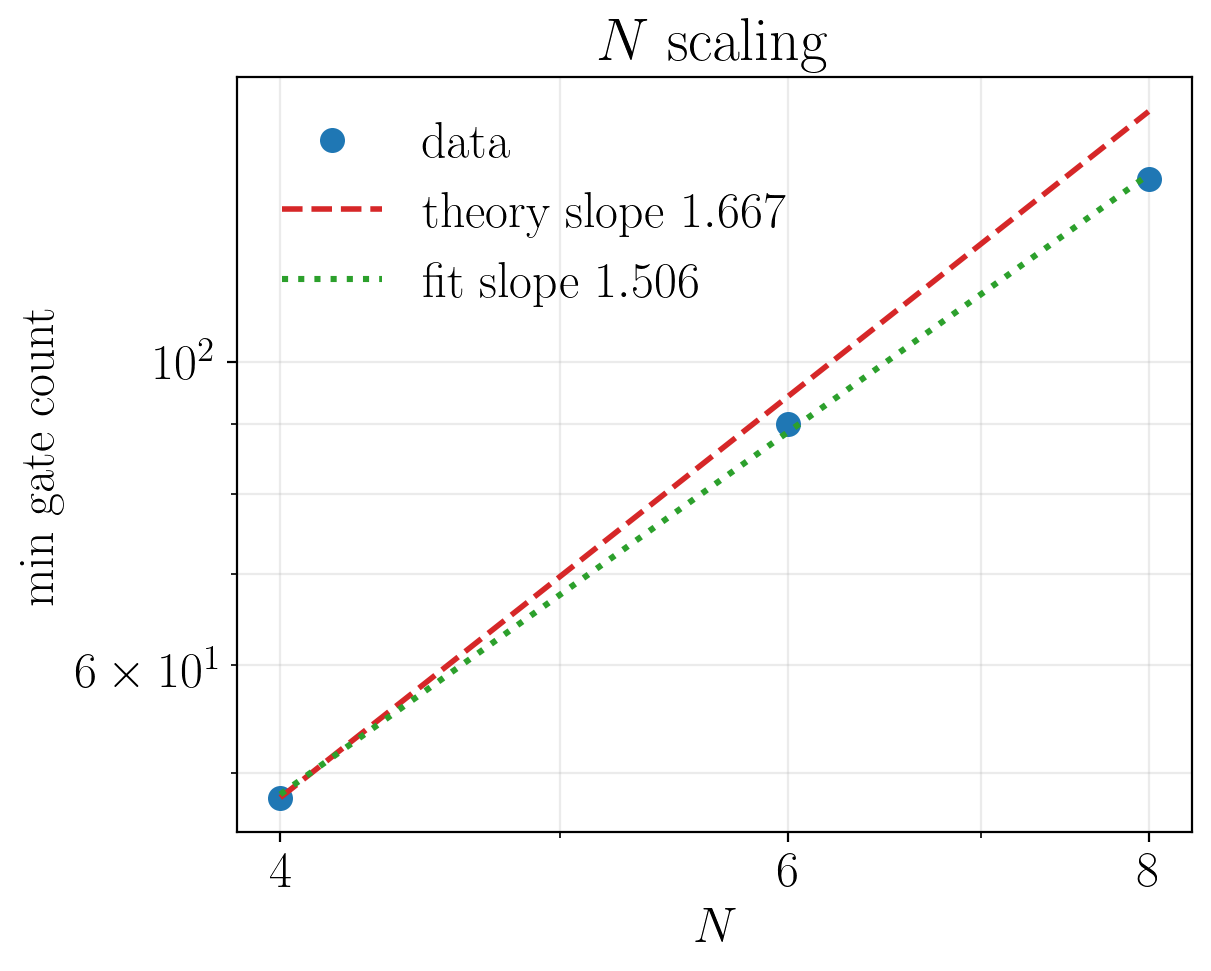

In [14]:
n_gate = []
for n in n_values:
    r_min, err = find_min_segments(caches[n], fixed_t_for_n, fixed_eps_for_n)
    n_gate.append(n * r_min)
    print(f"N sweep: N={n}, r_min={r_min}, err={err:.3e}, G={n*r_min}")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
slope_n = plot_panel(ax, n_values, n_gate, 5 / 3, r"$N$", r"$N$ scaling")
fig.tight_layout()
print(f"fitted slope (N): {slope_n:.3f}")
plt.show()


T sweep: T=0.5, r_min=6, err=9.202e-03, G=36
T sweep: T=0.75, r_min=10, err=9.570e-03, G=60
T sweep: T=1.0, r_min=15, err=8.516e-03, G=90
T sweep: T=1.5, r_min=25, err=8.924e-03, G=150
T sweep: T=2.0, r_min=36, err=9.176e-03, G=216
T sweep: T=3.0, r_min=60, err=9.671e-03, G=360
fitted slope (T): 1.289


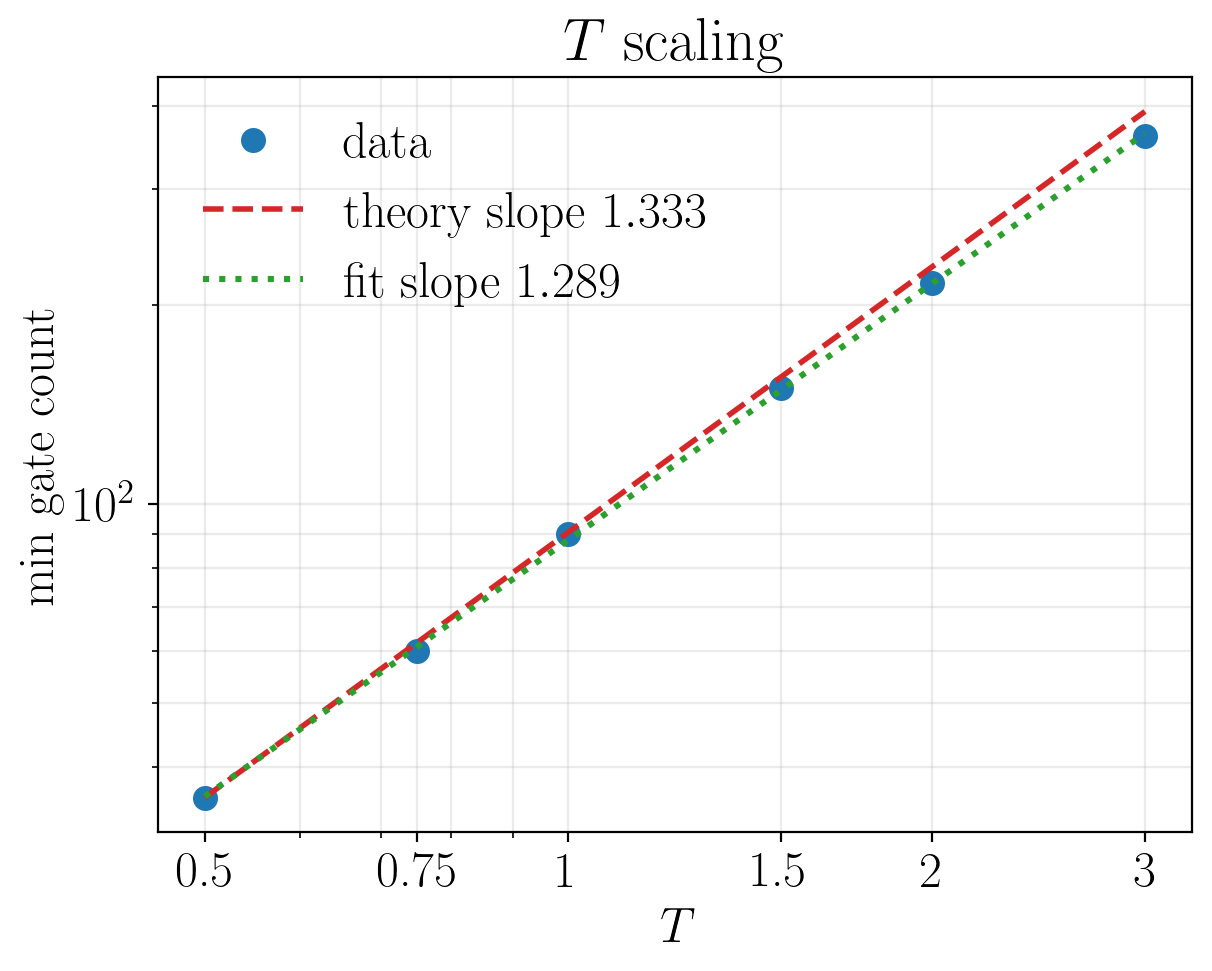

In [15]:
t_gate = []
for t_total in t_values:
    r_min, err = find_min_segments(caches[fixed_n_for_t], t_total, fixed_eps_for_t)
    t_gate.append(fixed_n_for_t * r_min)
    print(f"T sweep: T={t_total}, r_min={r_min}, err={err:.3e}, G={fixed_n_for_t*r_min}")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
slope_t = plot_panel(ax, t_values, t_gate, 4 / 3, r"$T$", r"$T$ scaling")
fig.tight_layout()
print(f"fitted slope (T): {slope_t:.3f}")
plt.show()


eps sweep: eps=0.02, r_min=12, err=1.832e-02, G=72
eps sweep: eps=0.015, r_min=13, err=1.390e-02, G=78
eps sweep: eps=0.01, r_min=15, err=8.516e-03, G=90
eps sweep: eps=0.007, r_min=16, err=6.840e-03, G=96
eps sweep: eps=0.005, r_min=18, err=4.599e-03, G=108
eps sweep: eps=0.003, r_min=21, err=2.750e-03, G=126
fitted slope (eps): -0.293


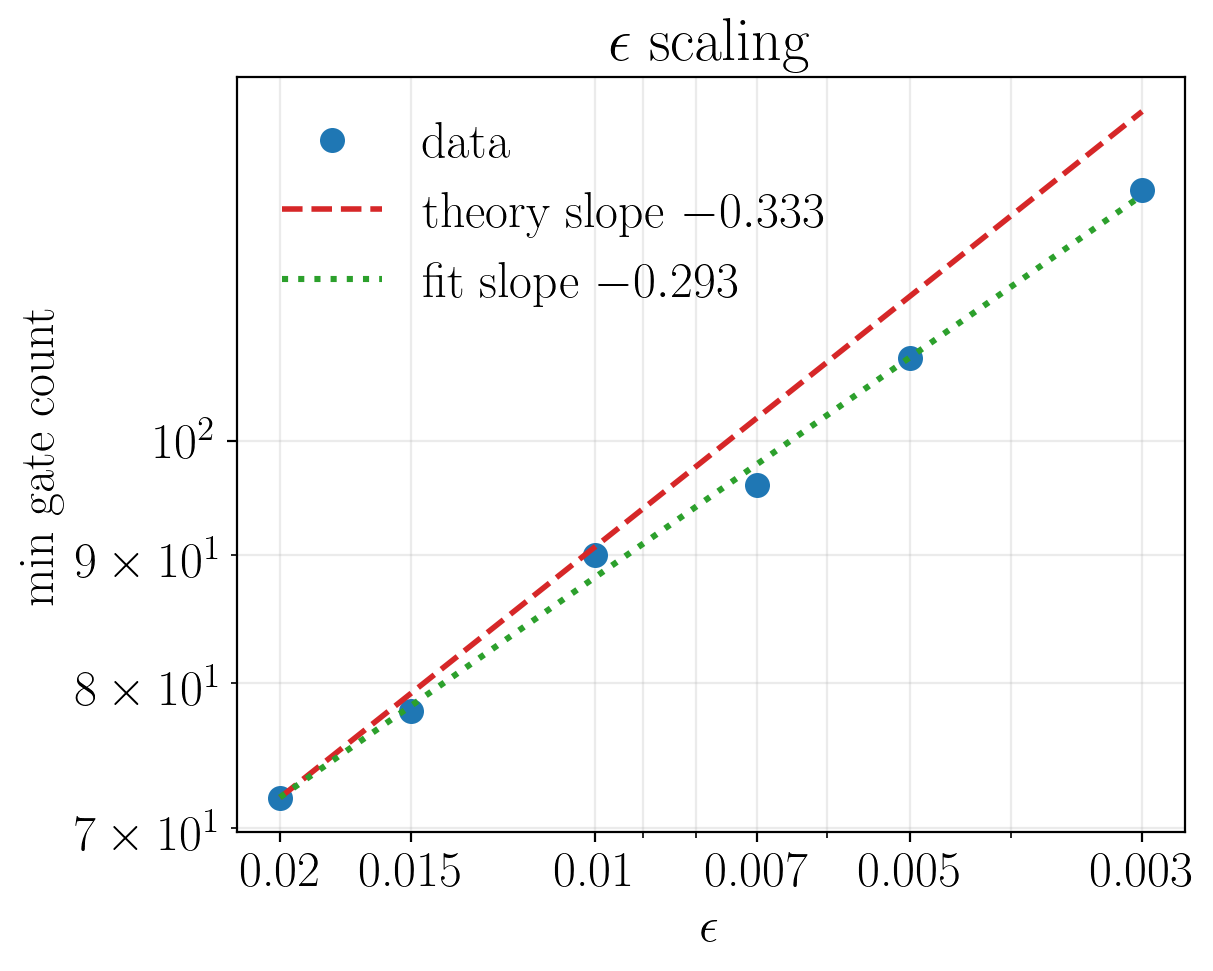

In [16]:
eps_gate = []
for eps in eps_values:
    r_min, err = find_min_segments(caches[fixed_n_for_eps], fixed_t_for_eps, eps)
    eps_gate.append(fixed_n_for_eps * r_min)
    print(f"eps sweep: eps={eps}, r_min={r_min}, err={err:.3e}, G={fixed_n_for_eps*r_min}")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
slope_eps = plot_panel(ax, eps_values, eps_gate, -1 / 3, r"$\epsilon$", r"$\epsilon$ scaling", invert_x=True)
fig.tight_layout()
print(f"fitted slope (eps): {slope_eps:.3f}")
plt.show()
